# Go proposal for hot subdwarf planet hosts

This notebook is used to prepare the GO proposal to search for planets around hot subdwarf. This has never been seen before, hence, the aim here is to use a few benchmark planets to explore the detectabilities with Plato.

The targets selected were chosen to cover a representative mix of cases, including sdB/sdO stars, different brightness levels, different numbers of cameras, and both normal and fast cadence cases. The current sample is:
The targets selected were chosen to cover a representative mix of cases, including sdB/sdO stars, different brightness levels, different numbers of cameras, and both normal and fast cadence cases. The current sample is:

- HD49798
- HD67269
- HD41571
- HD78401
- EC05275-5809
- CD-31 4800 (Cheops target)  

For all cases, I adopted a 90-day baseline. The main cadence is 50 s, and I also generated 25 s versions for HD49798 and HD67269 as additional fast-cadence cases.

For the stellar parameters, I used simple representative values at this stage:

- sdO: Mstar = 0.47 Msun, Rstar = 0.25 Rsun
- sdB: Mstar = 0.47 Msun, Rstar = 0.15 Rsun

For the injected planetary scenarios, I explored:

- orbital periods of 1.0, 2.0, 3.0, and 5.0 days
- planetary radii of 0.5, 1.25, and 2.0 Earth radii

This gives:

 - 7 target/cadence configurations for the benchmark sample
 - each sampled over 4 periods and 3 planetary radii
 - for a total of 96 noiseless light curves

I also generated folded diagnostic plots for all of them as a sanity check, and everything looks consistent. The files available in the shared link below (`**`) already correspond to the final adopted stellar classification, including CD-31 4800 as an sdO.

All the information about coordinates, brightness can be consulted in the manifest.csv and in the hot_subdwarf_master_table.csv

- Author: Nicholas Jannsen
- Last check: 2026-03-30
- platosim --version: `3.7.0-296-g089eb4b7`

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from pathlib import Path
from textwrap import dedent

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [166]:
# Set global paths
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_hotsd_planets'
idir = path / 'input'
fdir = path / 'figures'
sdir = path / 'simulations'

---
## 1. Show targets in sky
---

In [168]:
df_CD314800 = pd.read_feather(idir / 'starcat_CD-314800_targets.ftr')
df_EC05275  = pd.read_feather(idir / 'starcat_EC05275-5809_targets.ftr')
df_HD41571  = pd.read_feather(idir / 'starcat_HD41571_targets.ftr')
df_HD49798  = pd.read_feather(idir / 'starcat_HD49798_targets.ftr')
df_HD67269  = pd.read_feather(idir / 'starcat_HD67269_targets.ftr')
df_HD78401  = pd.read_feather(idir / 'starcat_HD78401_targets.ftr')
cat_CD314800 = SkyCoord(df_CD314800.ra, df_CD314800.dec, frame='icrs', unit=u.deg)
cat_EC05275  = SkyCoord(df_EC05275.ra, df_EC05275.dec, frame='icrs', unit=u.deg)
cat_HD41571  = SkyCoord(df_HD41571.ra, df_HD41571.dec, frame='icrs', unit=u.deg)
cat_HD49798  = SkyCoord(df_HD49798.ra, df_HD49798.dec, frame='icrs', unit=u.deg)
cat_HD67269  = SkyCoord(df_HD67269.ra, df_HD67269.dec, frame='icrs', unit=u.deg)
cat_HD78401  = SkyCoord(df_HD78401.ra, df_HD78401.dec, frame='icrs', unit=u.deg)
# Show all catalogue combined
df = pd.concat([df_CD314800, df_EC05275, df_HD41571, df_HD41571, df_HD49798, df_HD67269, df_HD78401])
df

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag
0,0.0,5592257426113535104,114.125677,-32.211956,10.467565,-0.490885,4.728634,0.046518,-25.772901,40.287980,1.272431,NaN,NaN,10.655580
0,0.0,4760261139199793792,82.075499,-58.113273,15.465185,-0.388511,0.482661,0.032901,7.821109,13.052301,1.069624,NaN,NaN,15.612948
0,0.0,2909968646602030336,91.180247,-28.060741,7.636814,-0.037127,2.689009,0.221102,-7.384800,1.602600,5.488786,NaN,NaN,7.650315
0,0.0,2909968646602030336,91.180247,-28.060741,7.636814,-0.037127,2.689009,0.221102,-7.384800,1.602600,5.488786,NaN,NaN,7.650315
0,0.0,5562023884304074240,102.019558,-44.316206,8.223742,-0.427691,1.919602,0.050080,-4.161746,5.925871,0.945559,NaN,NaN,8.386904
0,0.0,5520413038558513280,121.296040,-45.406810,8.658205,-0.034237,3.092602,0.177568,-9.714434,9.178251,6.912482,12400.292969,3.8921,8.670650
0,0.0,5326745919424790656,136.577897,-48.628579,9.295487,0.126412,2.009157,0.054582,-11.250023,7.208140,2.793253,NaN,NaN,9.250877


<IPython.core.display.Javascript object>


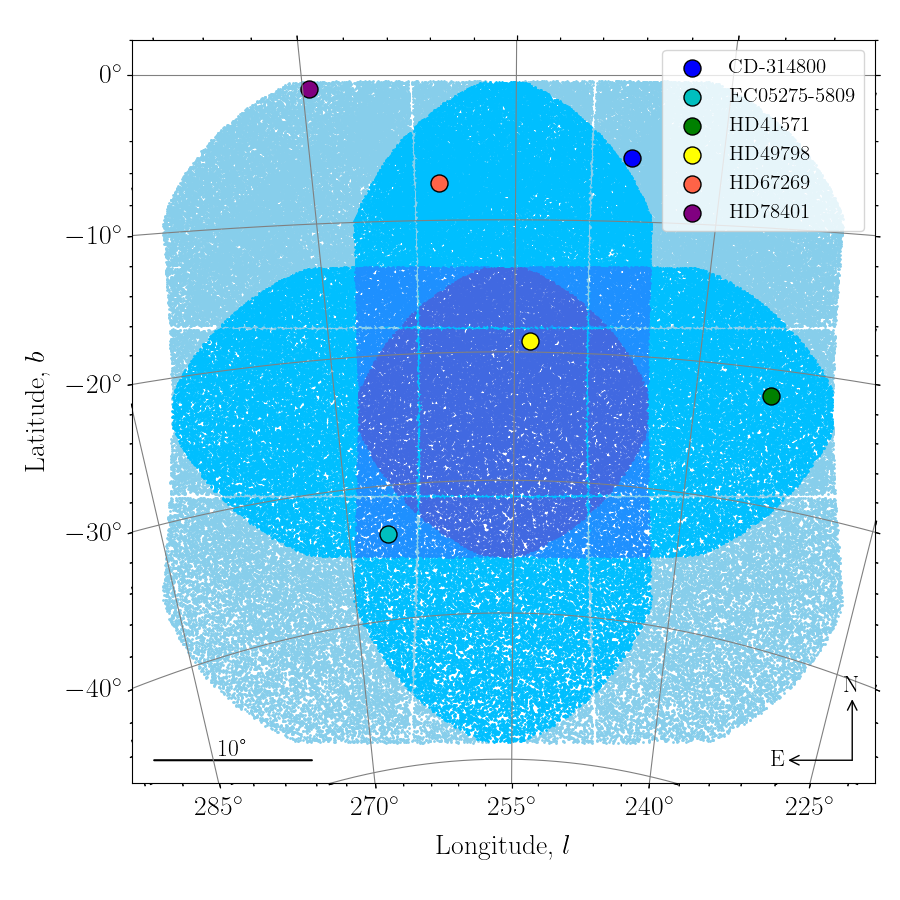

In [19]:
ms, ec = 150, 'k'
fig, ax = pt.plotPlatoFOV('LOPS2',ncamStars=True, clabel=r'$P$ [mag]', s=150, lw=0.3, figsize=(9,9))
ax.scatter(cat_CD314800.ra.deg, cat_CD314800.dec.deg, marker='o', c='blue', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='CD-314800')
ax.scatter(cat_EC05275.ra.deg, cat_EC05275.dec.deg, marker='o', c='c', ec=ec,  transform=ax.get_transform('icrs'), s=ms, label='EC05275-5809');
ax.scatter(cat_HD41571.ra.deg, cat_HD41571.dec.deg, marker='o', c='green', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD41571');
ax.scatter(cat_HD49798.ra.deg, cat_HD49798.dec.deg, marker='o', c='yellow', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD49798');
ax.scatter(cat_HD67269.ra.deg, cat_HD67269.dec.deg, marker='o', c='tomato', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD67269');
ax.scatter(cat_HD78401.ra.deg, cat_HD78401.dec.deg, marker='o', c='purple', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD78401');
ax.legend(loc='upper right')
fig.savefig(fdir / 'starcat_sky_targets.png', bbox_inches='tight', dpi=200)

---
## 2. Light curves from Francisco J. Pozuelos
---

In [50]:
df = pd.read_csv(sdir / 'templates/lightcurves/CD_314800_50s_P5.0d_Rp2.00Re.txt', names=['time', 'flux'], sep=' ')

<IPython.core.display.Javascript object>


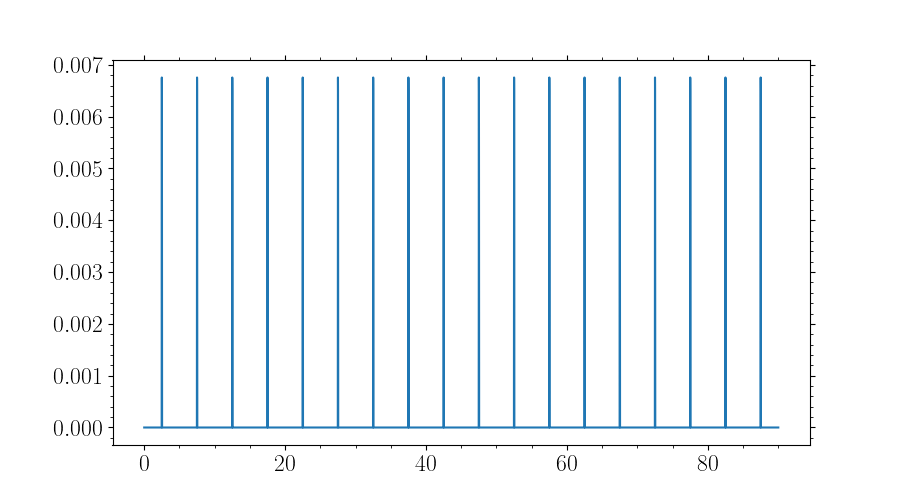

In [52]:
fig = plt.figure(figsize=(9,5))
plt.plot(df.time/86400, df.flux, '-');

---
## 3. Create SLURM parameter file
---

In [8]:
files = glob.glob(f'{sdir}/templates/varsource/*')
filenames = sorted([Path(f).stem for f in files])
# filenames

In [9]:
# Create sims parameter file
textfile = "id,group,camera,quarter,name,stem\n"
for idNo,nameNo in zip(range(1, len(filenames)+1), filenames):
    for groupNo in range(1,5):
        for cameraNo in range(1,7):
            for quarterNo in range(1,2):
                name = Path(nameNo).stem.split('_')[0]
                textfile += f"{idNo},{groupNo},{cameraNo},{quarterNo},{name},{nameNo}\n"
# Save file to input directory
with open(sdir / 'slurm/cluster_sims.data', "w") as ofile:
    ofile.write(dedent(textfile).strip())
# print(textfile)

In [15]:
# Create post parameter file
textfile = "name,stem\n"
for stem in filenames:
    name = Path(stem).stem.split('_')[0]
    textfile += f"{name},{stem}\n"
# Save file to input directory
with open(sdir / 'slurm/cluster_post.data', "w") as ofile:
    ofile.write(dedent(textfile).strip())
# print(textfile)

---
## 4. Analyse reduced light curves
---

In [159]:
# Choose star ID
name = 'CD-314800'
# stem = 'CD-314800_50s_P1.0d_Rp0.50Re'
# stem = 'CD-314800_50s_P1.0d_Rp1.25Re'
# stem = 'CD-314800_50s_P1.0d_Rp2.00Re'
# stem = 'CD-314800_50s_P2.0d_Rp0.50Re'
# stem = 'CD-314800_50s_P2.0d_Rp1.25Re'
# stem = 'CD-314800_50s_P2.0d_Rp2.00Re'
# stem = 'CD-314800_50s_P3.0d_Rp0.50Re'
# stem = 'CD-314800_50s_P3.0d_Rp1.25Re'
# stem = 'CD-314800_50s_P3.0d_Rp2.00Re'
# stem = 'CD-314800_50s_P5.0d_Rp0.50Re'
# stem = 'CD-314800_50s_P5.0d_Rp1.25Re'
stem = 'CD-314800_50s_P5.0d_Rp2.00Re'
idir = sdir / f'camera/{name}/{stem}'
odir = sdir / f'mission/{name}'
lcs = LightCurve(idir, mode='multi')
lcs.files(suffix='ftr')

['/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.1_Q1.ftr',
 '/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.2_Q1.ftr',
 '/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.3_Q1.ftr',
 '/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.4_Q1.ftr',
 '/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.5_Q1.ftr',
 '/lhome/nicholas/software/workdir/go_hotsd_planets/simulations/camera/CD-314800/CD-314800_50s_P5.0d_Rp2.00Re/000000001_Ncam2.6_Q1.ftr']

In [160]:
# Create table with simulation statistics
dt = lcs.stat_sim_table(ofile=odir/f'table_{stem}.ftr', clean=False)
dt.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 99.58it/s]                


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,1,5.592257e+18,114.125677,-32.211956,10.65558,2,1,1,3,723.970309,1517.615410,12.966966,14.331466,-55.162923,2,0.017789,0.002487
1,1,5.592257e+18,114.125677,-32.211956,10.65558,2,2,1,3,715.213538,1527.378759,12.920877,14.173844,-54.987182,2,0.015470,0.002487
2,1,5.592257e+18,114.125677,-32.211956,10.65558,2,3,1,3,716.621123,1526.158956,12.926944,14.199180,-55.009139,2,0.013336,0.002465
3,1,5.592257e+18,114.125677,-32.211956,10.65558,2,4,1,3,725.572057,1513.750332,12.983361,14.360297,-55.232494,2,0.017784,0.002473
4,1,5.592257e+18,114.125677,-32.211956,10.65558,2,5,1,3,706.396665,1534.010656,12.886771,14.015140,-54.867808,2,0.012055,0.002469


<IPython.core.display.Javascript object>


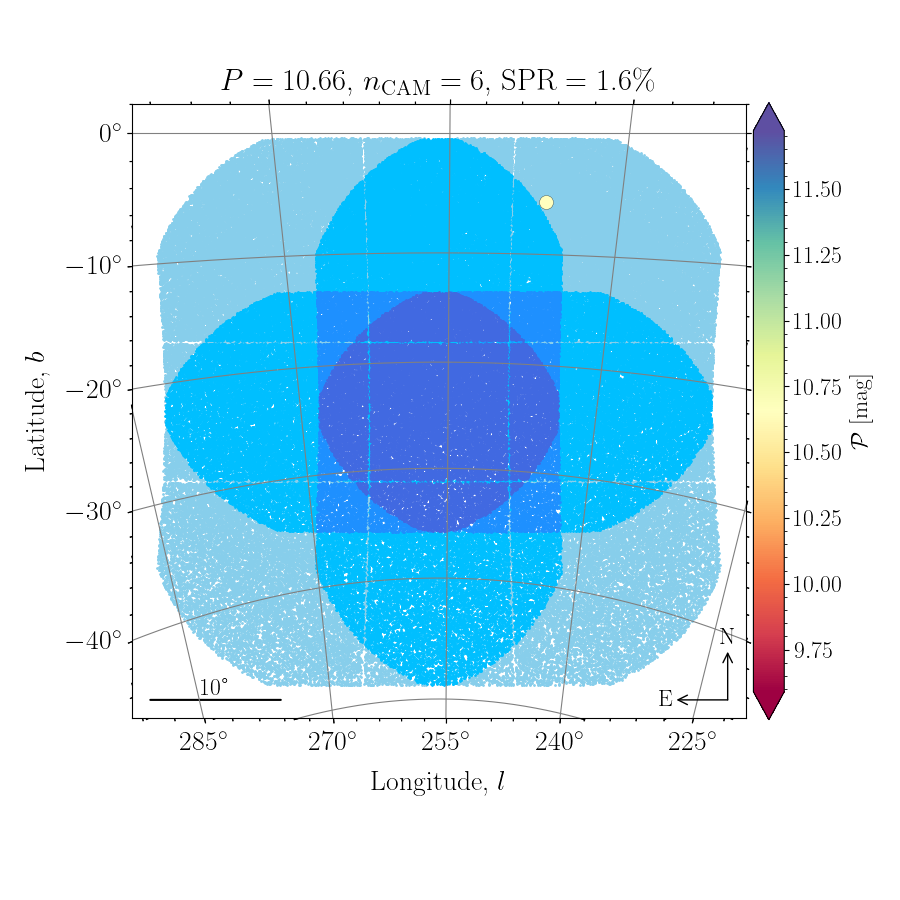

In [161]:
# Plot the target in sky
dx = dt.iloc[0]
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=29,
    raStars=dx.ra, decStars=dx.dec, c=dx.mag, ncamStars=True,
    clabel=r'$\mathcal{P}$ [mag]', s=400, lw=0.2, figsize=(9,9),
    title=rf'$P={dt.mag.iloc[0]:.2f}$, '+r'$n_{\rm CAM}='+f'{dt.shape[0]:.0f}$, SPR = {dt.SPR.mean()*100:.1f}\%'
)

<IPython.core.display.Javascript object>


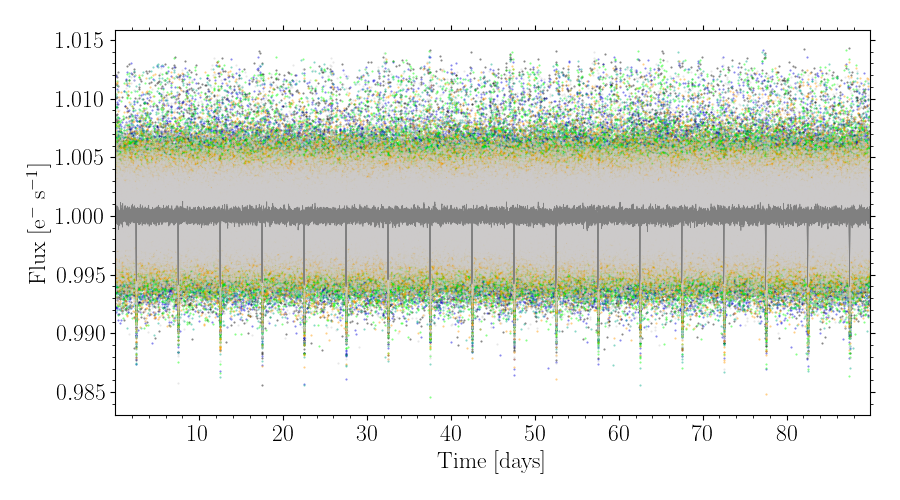

In [162]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5));

In [163]:
# Post-processing into final light curve
lc = lcs.merge(
    suffix='ftr',
    flux_detrend='wotan', 
    flux_group_mean=True,
    binsize=50,
    clip_sigma=True, clip_lower=10, clip_upper=3,
    flux_offset=True,
    flux_error=True,
    ofile=odir/f'lc_{stem}.ftr'
)

Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.54it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:19.710469 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


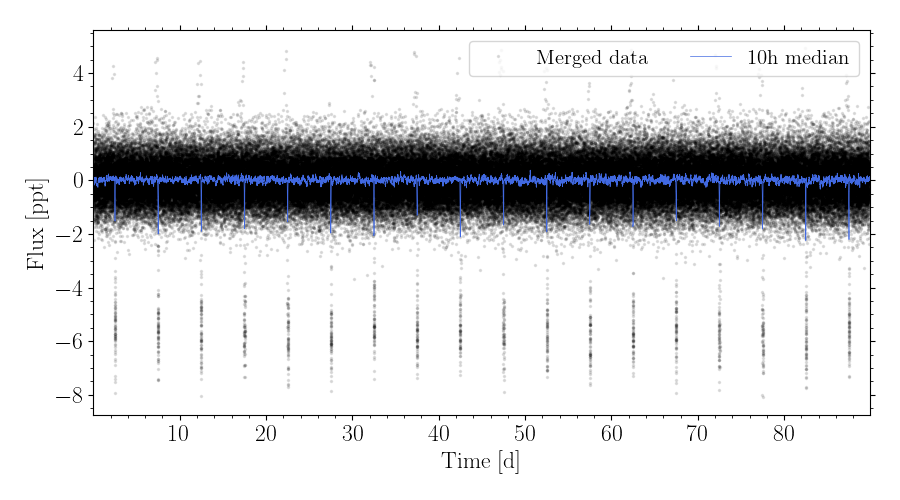

In [164]:
# Show result
lc.plot(input_model=True, flux_unit='ppt', flux_error=False, median_filter=10, alpha=0.1, figsize=(9,5));
fig.savefig(odir/f'plot_{stem}.png', bbox_inches='tight', dpi=200)

### Run script to reduce all planet-configurations per target

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 44.46it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.64it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:19.498065 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


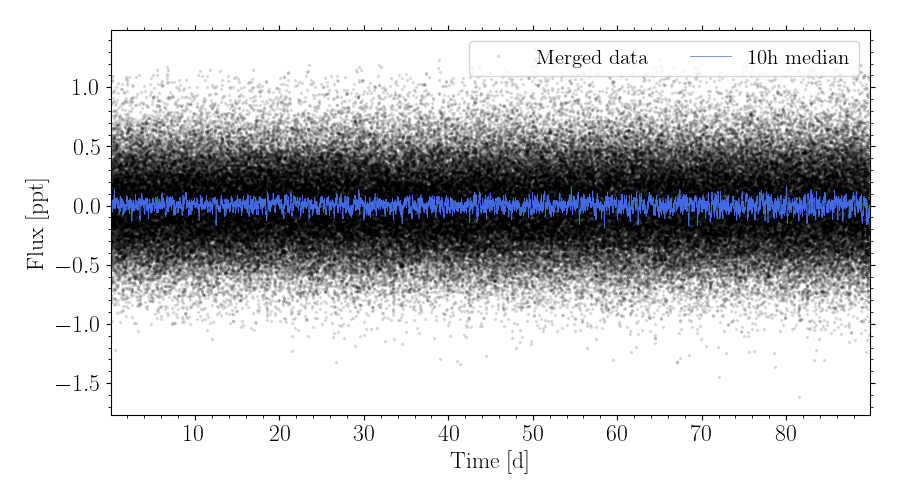

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 59.10it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.96it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:20.629013 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


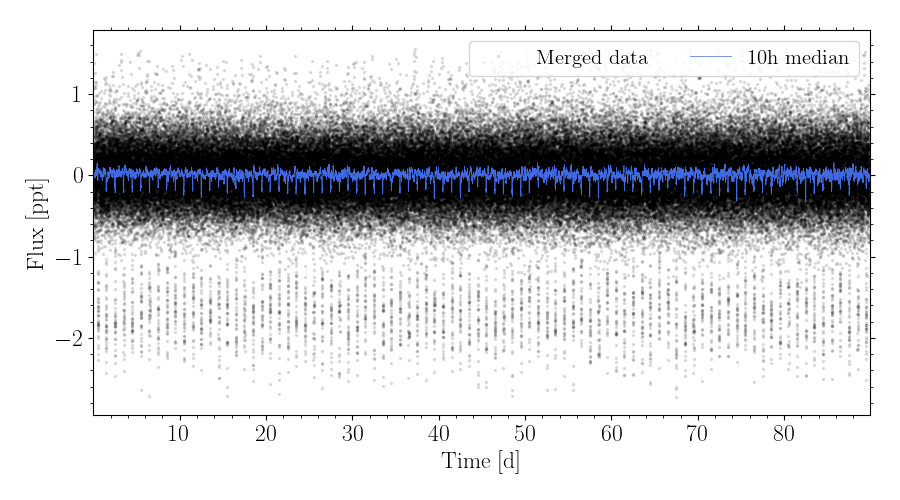

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.90it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00,  8.89it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:22.749065 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


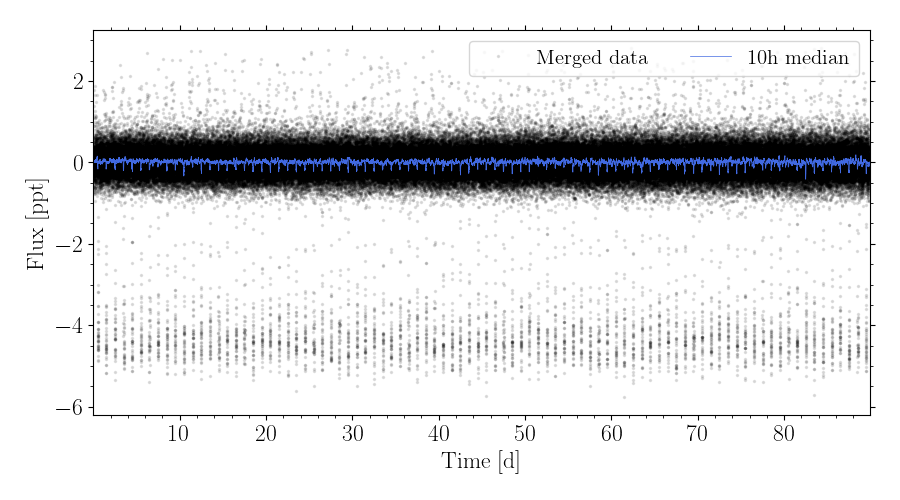

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 52.01it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00,  9.80it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:22.679666 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


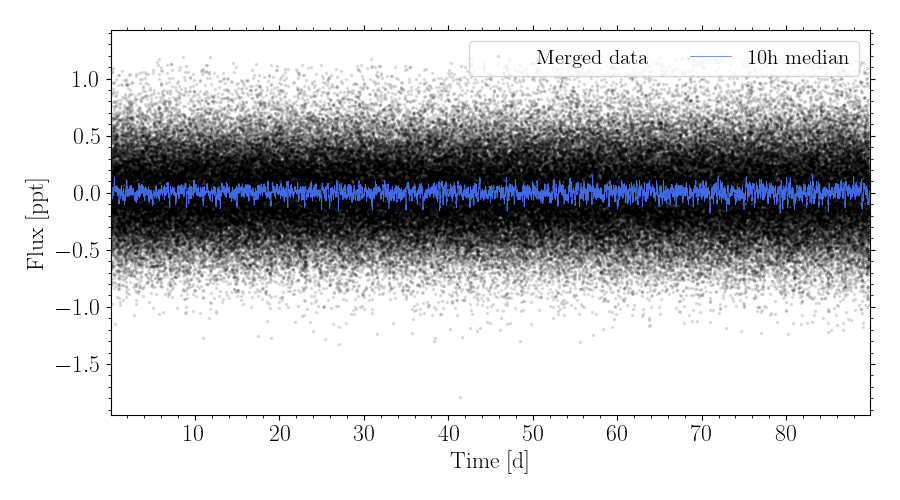

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 52.71it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00,  9.97it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:21.873339 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


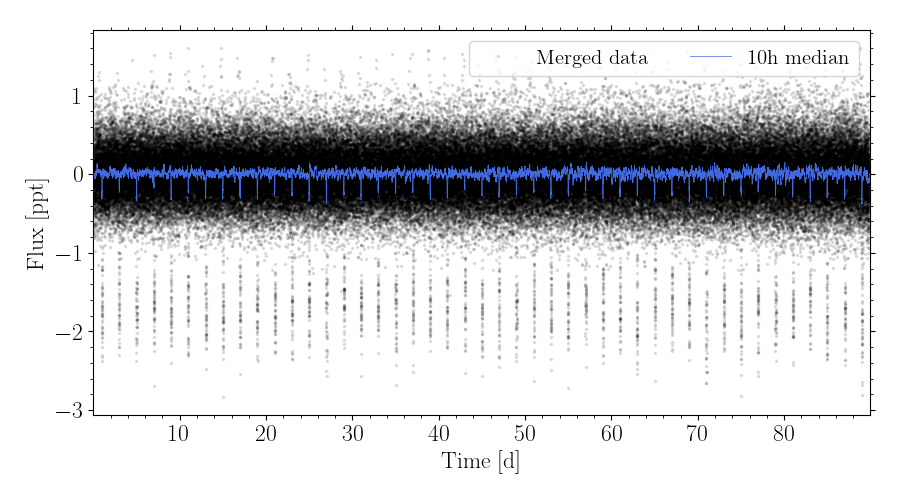

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 56.13it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.22it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:21.714657 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


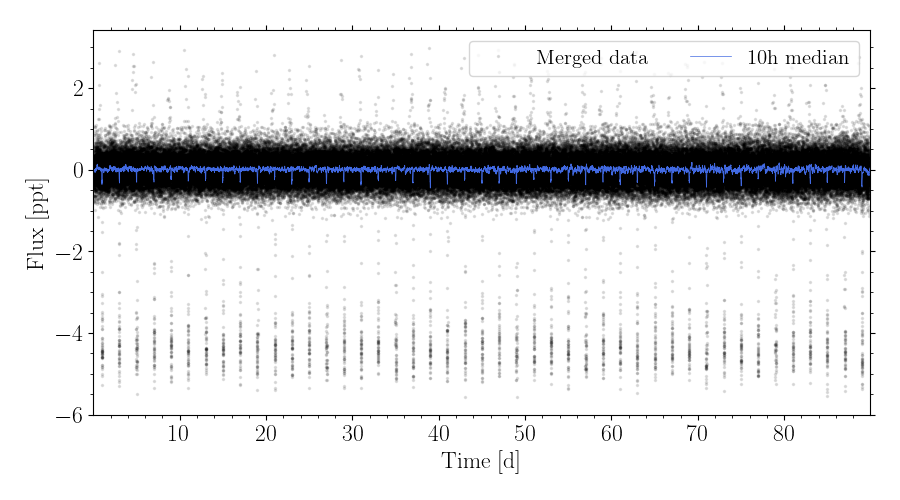

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 49.46it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.55it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:21.110910 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


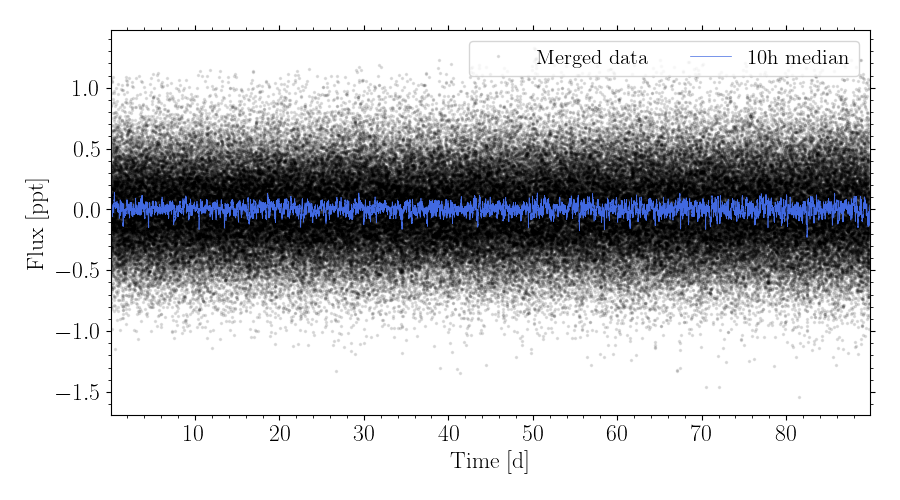

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.59it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.98it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:20.945031 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


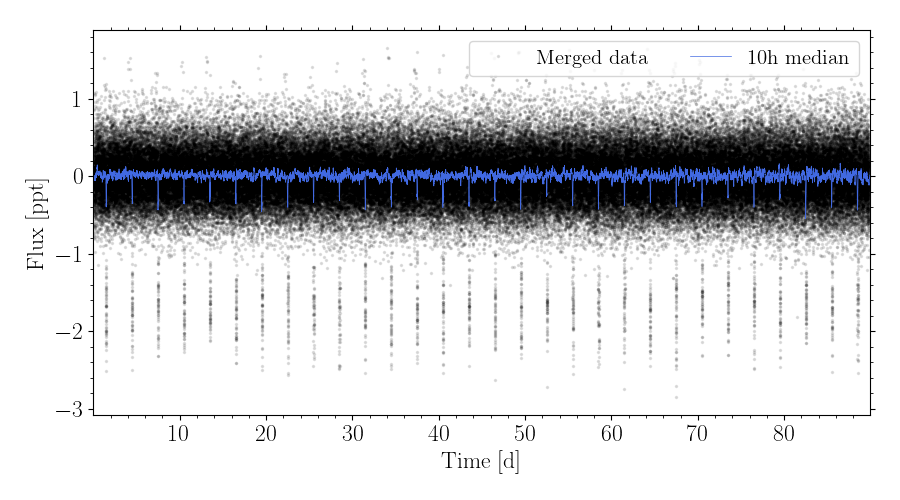

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.90it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.61it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:21.020805 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


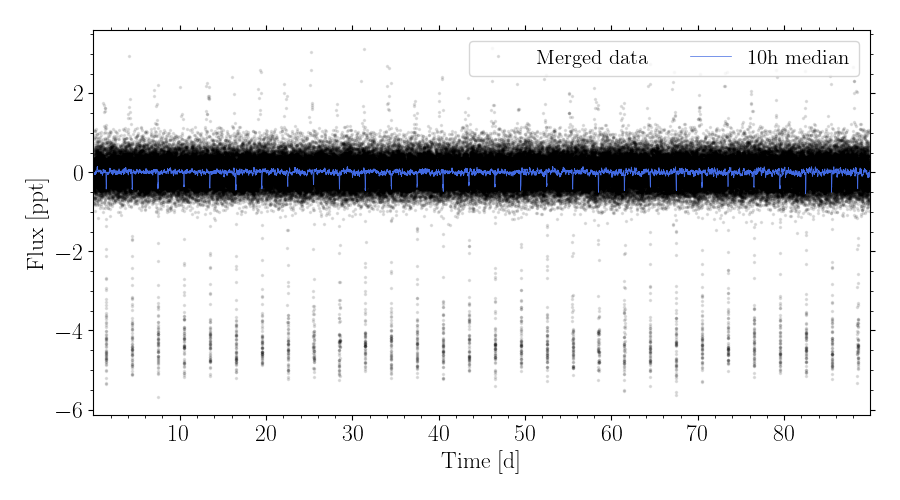

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.62it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.10it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:20.870275 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


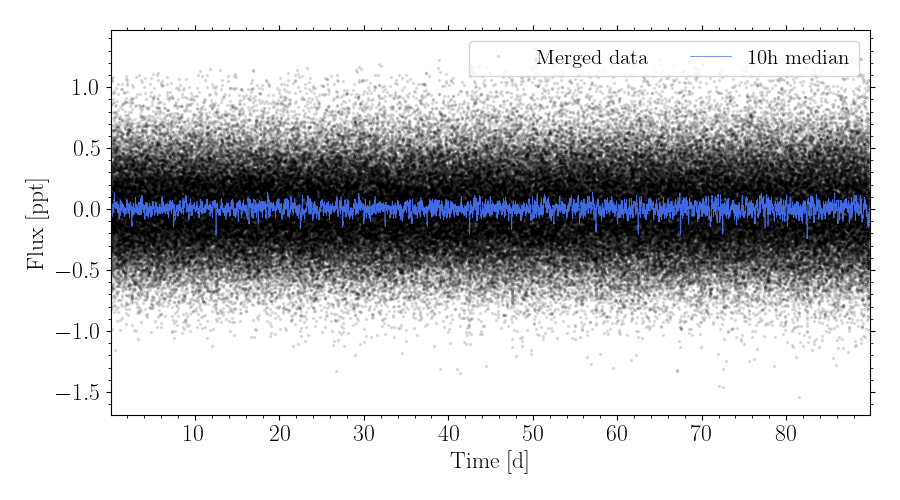

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 51.49it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 11.04it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:21.121736 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


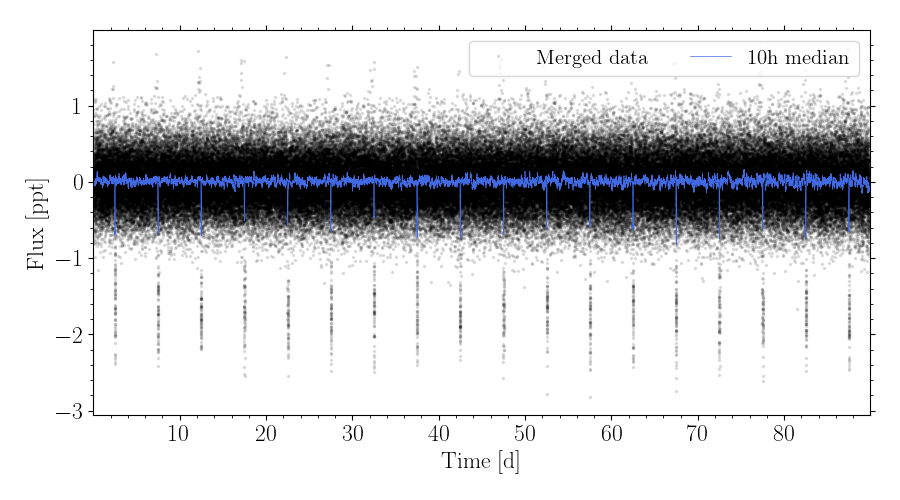

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.68it/s]                


Processing star ID 000000001
-------------------------------------------------------
Merging 6 light curves


100%|██████████████████████████████████████████████████| 6/6 [00:00<00:00, 10.79it/s]                


Sorting data after timings
Averaging data from same camera group
Binning data per 50s
Removing outliers
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:20.920631 [h:mm:ss]
-------------------------------------------------------


<IPython.core.display.Javascript object>


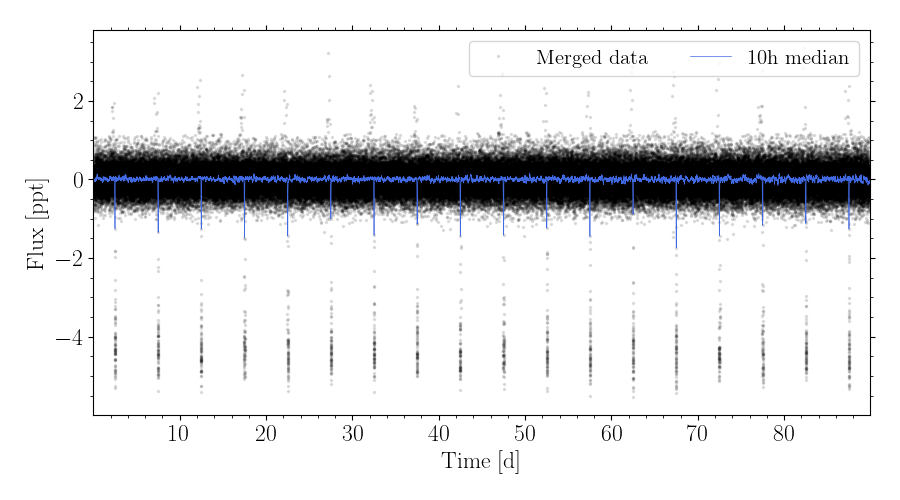

In [174]:
# Choose star ID
cadence = 50
# name = 'CD-314800'
# name = 'EC05275-5809'
# name = 'HD41571'
# name = 'HD49798'
# name = 'HD67269'
name = 'HD78401'
#-------------------------------
P = ['1.0', '2.0', '3.0', '5.0']
Rp =['0.50', '1.25', '2.00']
for p in P:
    for r in Rp:
        # Handle I/O
        stem = f'{name}_{cadence}s_P{p}d_Rp{r}Re'
        idir = sdir / f'camera/{name}/{stem}'
        odir = sdir / f'mission/{name}'
        lcs = LightCurve(idir, mode='multi')
        lcs.files(suffix='ftr')
        # Create table with simulation statistics
        dt = lcs.stat_sim_table(ofile=odir/f'table_{stem}.ftr', clean=False)
        # Post-processing into final light curve
        lc = lcs.merge(
            suffix='ftr',
            flux_detrend='wotan', 
            flux_group_mean=True,
            binsize=50,
            clip_sigma=True, clip_lower=10, clip_upper=3,
            flux_offset=True,
            flux_error=True,
            ofile=odir/f'lc_{stem}.ftr'
        )
        # Show result
        fig, ax = lc.plot(input_model=True, flux_unit='ppt', flux_error=False, median_filter=10, alpha=0.1, figsize=(9,5));
        fig.savefig(odir/f'plot_{stem}.png', bbox_inches='tight', dpi=200)